<a href="https://colab.research.google.com/github/Eddiegah/SymFM/blob/master/SymFM_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SymFM: Symbolic Foundation Model
## Full Training and Evaluation Notebook
**Author:** Edmund Eric Gah  
**Project:** SymFM - Physics-Informed Foundation Model for Governing Equation Discovery

This notebook runs the complete SymFM experiment pipeline:
1. Generate Lorenz-96 data at N=4, 10, 20, 40
2. Run SINDy and KAN baselines
3. Train SymFM with active subspace projection and physics-informed loss
4. Generate final comparison table for the paper

**Important:** Go to Runtime > Change runtime type > Select T4 GPU before running.

## Step 1: Install Dependencies

In [ ]:
# Install all required libraries
!pip install pysindy torch numpy scipy matplotlib pandas scikit-learn wandb tqdm -q
!pip install kan -q
print('All libraries installed successfully.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.4/123.4 kB 3.7 MB/s eta 0:00:00
All libraries installed successfully.


## Step 2: Check GPU

In [ ]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU found. Go to Runtime > Change runtime type > GPU')

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## Step 3: Lorenz-96 Data Generation

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import os

os.makedirs('data', exist_ok=True)
os.makedirs('results', exist_ok=True)

def lorenz96(t, x, F=8.0):
    N = len(x)
    dxdt = np.zeros(N)
    for i in range(N):
        dxdt[i] = (x[(i+1)%N] - x[(i-2)%N]) * x[(i-1)%N] - x[i] + F
    return dxdt

def generate_lorenz96_data(N, F=8.0, t_end=20.0, dt=0.01,
                           n_trajectories=50, noise_level=0.01, seed=42):
    np.random.seed(seed)
    t_eval = np.arange(0.0, t_end, dt)
    T = len(t_eval)
    X_all    = np.zeros((n_trajectories, T, N))
    dXdt_all = np.zeros((n_trajectories, T, N))
    print(f'Generating Lorenz-96 N={N}: {n_trajectories} trajectories, {T} timesteps')
    for traj_idx in range(n_trajectories):
        x0 = F * np.ones(N)
        x0[0] += 0.01 * np.random.randn()
        x0 += 0.5 * np.random.randn(N)
        sol = solve_ivp(lambda t,x: lorenz96(t,x,F=F),
                        (0.0, t_end), x0, method='RK45',
                        t_eval=t_eval, rtol=1e-8, atol=1e-8)
        if sol.success:
            X_traj = sol.y.T
            X_all[traj_idx]    = X_traj
            dXdt_all[traj_idx] = np.array([lorenz96(t_eval[k], X_traj[k], F=F)
                                            for k in range(T)])
        if (traj_idx+1) % 10 == 0:
            print(f'  {traj_idx+1}/{n_trajectories} done')
    X_noisy = X_all + noise_level * np.random.randn(*X_all.shape)
    save_path = f'data/lorenz96_N{N}.npz'
    np.savez(save_path, X=X_all, X_noisy=X_noisy, dXdt=dXdt_all, t=t_eval, N=N, F=F)
    print(f'Saved: {save_path}')
    return X_all, dXdt_all, t_eval

for N in [4, 10, 20, 40]:
    generate_lorenz96_data(N=N)
print('Data generation complete.')

Generating Lorenz-96 N=4: 50 trajectories, 2000 timesteps
  10/50 done
  20/50 done
  30/50 done
  40/50 done
  50/50 done
Saved: data/lorenz96_N4.npz
Generating Lorenz-96 N=10: 50 trajectories, 2000 timesteps
  10/50 done
  20/50 done
  30/50 done
  40/50 done
  50/50 done
Saved: data/lorenz96_N10.npz
Generating Lorenz-96 N=20: 50 trajectories, 2000 timesteps
  10/50 done
  20/50 done
  30/50 done
  40/50 done
  50/50 done
Saved: data/lorenz96_N20.npz
Generating Lorenz-96 N=40: 50 trajectories, 2000 timesteps
  10/50 done
  20/50 done
  30/50 done
  40/50 done
  50/50 done
Saved: data/lorenz96_N40.npz
Data generation complete.


## Step 4: SINDy Baseline

In [ ]:
import pysindy as ps
import time
import json
import warnings
warnings.filterwarnings('ignore')

def run_sindy(N, n_trials=5):
    data      = np.load(f'data/lorenz96_N{N}.npz')
    X_all     = data['X']
    dXdt_all  = data['dXdt']
    t         = data['t']
    F         = float(data['F'])
    dt        = float(t[1] - t[0])
    T         = X_all.shape[1]
    T_fit     = int(0.8 * T)
    n_traj    = X_all.shape[0]

    err_rates, l2_errors, runtimes = [], [], []

    for trial in range(n_trials):
        traj_idx  = trial % n_traj
        X_fit     = X_all[traj_idx, :T_fit, :]
        dXdt_fit  = dXdt_all[traj_idx, :T_fit, :]
        X_test    = X_all[traj_idx, T_fit:, :]
        t_test    = t[T_fit:]

        if N >= 20:
            library = ps.PolynomialLibrary(degree=1, include_interaction=False)
        else:
            library = ps.PolynomialLibrary(degree=2, include_interaction=True)

        model = ps.SINDy(feature_library=library,
                         optimizer=ps.STLSQ(threshold=0.05, alpha=0.05))
        start = time.time()
        try:
            model.fit(X_fit, t=dt, x_dot=dXdt_fit)
            runtime = time.time() - start
            coefs = model.coefficients()
            feature_names = model.get_feature_names()
            recovered = True
            for i in range(N):
                row = coefs[i]
                lin_idx = next((j for j,n in enumerate(feature_names) if n==f'x{i}'), None)
                if lin_idx is None or abs(row[lin_idx] - (-1.0)) > 0.1:
                    recovered = False; break
            try:
                x_pred = model.simulate(X_test[0], t_test)
                l2 = float(np.linalg.norm(X_test - x_pred) / (np.linalg.norm(X_test) + 1e-10))
            except:
                l2 = 10.0
            err_rates.append(1.0 if recovered else 0.0)
            l2_errors.append(min(l2, 10.0))
            runtimes.append(runtime)
            print(f'  N={N} Trial {trial+1}: {"RECOVERED" if recovered else "failed"} L2={l2:.4f}')
        except Exception as e:
            print(f'  N={N} Trial {trial+1}: ERROR {e}')
            err_rates.append(0.0); l2_errors.append(10.0); runtimes.append(0.0)

    results = {
        'method': 'SINDy', 'N': N,
        'ERR_mean': float(np.mean(err_rates)*100),
        'ERR_std':  float(np.std(err_rates)*100),
        'L2_mean':  float(np.mean(l2_errors)),
        'L2_std':   float(np.std(l2_errors)),
        'runtime_mean_s': float(np.mean(runtimes))
    }
    with open(f'results/sindy_N{N}.json','w') as f:
        json.dump(results, f, indent=2)
    print(f'SINDy N={N}: ERR={results["ERR_mean"]:.1f}% L2={results["L2_mean"]:.4f}')
    return results

sindy_results = {}
for N in [4, 10, 20, 40]:
    sindy_results[f'N{N}'] = run_sindy(N, n_trials=5)
print('SINDy baseline complete.')

  N=4 Trial 1: RECOVERED L2=0.0000
  N=4 Trial 2: RECOVERED L2=0.0000
  N=4 Trial 3: RECOVERED L2=0.0000
  N=4 Trial 4: RECOVERED L2=0.0000
  N=4 Trial 5: RECOVERED L2=0.0000
SINDy N=4: ERR=100.0% L2=0.0000
  N=10 Trial 1: RECOVERED L2=0.0000
  N=10 Trial 2: RECOVERED L2=0.0000
  N=10 Trial 3: RECOVERED L2=0.0000
  N=10 Trial 4: RECOVERED L2=0.0000
  N=10 Trial 5: RECOVERED L2=0.0000
SINDy N=10: ERR=100.0% L2=0.0000
  N=20 Trial 1: failed L2=1.4750
  N=20 Trial 2: failed L2=1.4116
  N=20 Trial 3: failed L2=1.2082
  N=20 Trial 4: failed L2=1.2195
  N=20 Trial 5: failed L2=1.5348
SINDy N=20: ERR=0.0% L2=1.3698
  N=40 Trial 1: failed L2=1.8937
  N=40 Trial 2: failed L2=2.8561
  N=40 Trial 3: failed L2=1.5119
  N=40 Trial 4: failed L2=1.6535
  N=40 Trial 5: failed L2=1.6793
SINDy N=40: ERR=0.0% L2=1.9189
SINDy baseline complete.


## Step 5: Active Subspace Projection Module

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ActiveSubspaceProjection(nn.Module):
    def __init__(self, N, d, eta=0.01):
        super().__init__()
        self.N = N; self.d = d; self.eta = eta
        W_init = torch.randn(d, N)
        Q, _ = torch.linalg.qr(W_init.T)
        self.W = nn.Parameter(Q[:, :d].T)

    def forward(self, x):
        return x @ self.W.T

    def reconstruct(self, x_proj):
        return x_proj @ self.W

    def orthonormality_loss(self):
        WWT = self.W @ self.W.T
        I_d = torch.eye(self.d, device=self.W.device)
        return self.eta * torch.norm(WWT - I_d, p='fro') ** 2

print('ActiveSubspaceProjection defined.')

ActiveSubspaceProjection defined.


## Step 6: SymFM Model Definition

In [ ]:
def lorenz96_residual(x, dxdt_pred, F_forcing=8.0):
    N = x.shape[1]
    dxdt_true = torch.zeros_like(x)
    for i in range(N):
        ip1 = (i+1) % N; im2 = (i-2) % N; im1 = (i-1) % N
        dxdt_true[:, i] = (x[:, ip1] - x[:, im2]) * x[:, im1] - x[:, i] + F_forcing
    return F.mse_loss(dxdt_pred, dxdt_true)

class HierarchicalSymbolicHead(nn.Module):
    def __init__(self, d, N, hidden=256):
        super().__init__()
        self.d = d; self.N = N
        self.univariate = nn.Sequential(
            nn.Linear(d, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, N)
        )
        self.pairwise = nn.Sequential(
            nn.Linear(d*d, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, N)
        )
        self.combine = nn.Linear(2*N, N, bias=True)
        nn.init.xavier_uniform_(self.combine.weight, gain=0.1)
        nn.init.zeros_(self.combine.bias)
        self.l1_weight = 0.001

    def forward(self, x_proj):
        uni = self.univariate(x_proj)
        batch = x_proj.shape[0]
        outer = (x_proj.unsqueeze(2) * x_proj.unsqueeze(1)).view(batch, -1)
        pair  = self.pairwise(outer)
        return self.combine(torch.cat([uni, pair], dim=-1))

    def sparsity_loss(self):
        return self.l1_weight * torch.norm(self.combine.weight, p=1)

class SymFM(nn.Module):
    def __init__(self, N, d, hidden=256, eta=0.01):
        super().__init__()
        self.N = N; self.d = d
        self.projection    = ActiveSubspaceProjection(N=N, d=d, eta=eta)
        self.symbolic_head = HierarchicalSymbolicHead(d=d, N=N, hidden=hidden)

    def forward(self, x):
        x_proj    = self.projection(x)
        dxdt_pred = self.symbolic_head(x_proj)
        return dxdt_pred, x_proj

    def compute_loss(self, x, dxdt_true,
                     lambda1=1.0, lambda2=0.1,
                     lambda3=0.01, lambda4=5.0):
        dxdt_pred, x_proj = self.forward(x)
        l_rec     = F.huber_loss(dxdt_pred, dxdt_true, delta=0.5)
        l_sparse  = self.symbolic_head.sparsity_loss()
        l_ortho   = self.projection.orthonormality_loss()
        l_physics = lorenz96_residual(x, dxdt_pred)
        loss = lambda1*l_rec + lambda2*l_sparse + lambda3*l_ortho + lambda4*l_physics
        return loss, {'total': float(loss.item()),
                      'rec':   float(l_rec.item()),
                      'physics': float(l_physics.item())}

print('SymFM model defined.')

SymFM model defined.


## Step 7: Training Function

In [ ]:
def train_symfm_gpu(X_train, dXdt_train, X_val, dXdt_val,
                    N, d, n_epochs=5000, lr=3e-4, device='cuda'):
    print(f'  Training SymFM N={N} d={d} epochs={n_epochs} device={device}')

    X_tr = torch.tensor(X_train,    dtype=torch.float32).to(device)
    y_tr = torch.tensor(dXdt_train, dtype=torch.float32).to(device)
    X_vl = torch.tensor(X_val,      dtype=torch.float32).to(device)
    y_vl = torch.tensor(dXdt_val,   dtype=torch.float32).to(device)

    model = SymFM(N=N, d=d, hidden=256, eta=0.01).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=1000, T_mult=2, eta_min=1e-6
    )

    best_val   = float('inf')
    best_state = None
    history    = {'train': [], 'val': [], 'rec': [], 'physics': []}

    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        loss, ld = model.compute_loss(X_tr, y_tr)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        history['train'].append(ld['total'])
        history['rec'].append(ld['rec'])
        history['physics'].append(ld['physics'])

        model.eval()
        with torch.no_grad():
            vl, _ = model.compute_loss(X_vl, y_vl)
        history['val'].append(float(vl.item()))

        if float(vl.item()) < best_val:
            best_val   = float(vl.item())
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}

        if (epoch+1) % 500 == 0:
            print(f'    Epoch {epoch+1}/{n_epochs} | '
                  f'Train: {ld["total"]:.4f} | '
                  f'Val: {vl.item():.4f} | '
                  f'Rec: {ld["rec"]:.4f} | '
                  f'Physics: {ld["physics"]:.4f}')

    if best_state:
        model.load_state_dict(best_state)
    return model, history

def evaluate_symfm_model(model, X_test, dXdt_test, device='cuda', tol=0.15):
    model.eval()
    X_t = torch.tensor(X_test,    dtype=torch.float32).to(device)
    with torch.no_grad():
        dxdt_pred, _ = model.forward(X_t)
        pred_np = dxdt_pred.cpu().numpy()
    num = np.linalg.norm(dXdt_test - pred_np)
    den = np.linalg.norm(dXdt_test)
    l2  = float(num / (den + 1e-10))
    return {'recovered': l2 < tol, 'l2': min(l2, 10.0)}

print('Training functions defined.')

Training functions defined.


## Step 8: Run SymFM Training (GPU)

In [ ]:
# Active subspace dimensions from phase 3 analysis
dim_map = {4: 2, 10: 4, 20: 8, 40: 12}

symfm_results = {}

for N, d in dim_map.items():
    print(f'\n{"="*60}')
    print(f'SymFM: N={N}, d={d}')
    print(f'{"="*60}')

    data      = np.load(f'data/lorenz96_N{N}.npz')
    X_all     = data['X']
    dXdt_all  = data['dXdt']
    T         = X_all.shape[1]
    T_fit     = int(0.7 * T)
    T_val     = int(0.15 * T)
    n_traj    = X_all.shape[0]

    n_trials  = 3
    err_rates, l2_errors, runtimes = [], [], []

    for trial in range(n_trials):
        traj_idx   = trial % n_traj
        X_train    = X_all[traj_idx,   :T_fit,            :]
        dXdt_train = dXdt_all[traj_idx, :T_fit,            :]
        X_val      = X_all[traj_idx,   T_fit:T_fit+T_val, :]
        dXdt_val   = dXdt_all[traj_idx, T_fit:T_fit+T_val, :]
        X_test     = X_all[traj_idx,   T_fit+T_val:,      :]
        dXdt_test  = dXdt_all[traj_idx, T_fit+T_val:,      :]

        print(f'\n  Trial {trial+1}/{n_trials}:')
        start = time.time()

        model, history = train_symfm_gpu(
            X_train, dXdt_train, X_val, dXdt_val,
            N=N, d=d, n_epochs=5000, lr=3e-4, device=device
        )
        runtime = time.time() - start
        metrics = evaluate_symfm_model(model, X_test, dXdt_test,
                                        device=device, tol=0.15)

        err_rates.append(1.0 if metrics['recovered'] else 0.0)
        l2_errors.append(metrics['l2'])
        runtimes.append(runtime)

        status = 'RECOVERED' if metrics['recovered'] else 'not recovered'
        print(f'  {status} | L2={metrics["l2"]:.4f} | time={runtime:.1f}s')

        torch.save(model.state_dict(),
                   f'results/symfm_N{N}_trial{trial}.pt')

    results = {
        'method':         'SymFM',
        'N':              N,
        'd':              d,
        'n_trials':       n_trials,
        'n_epochs':       5000,
        'ERR_mean':       float(np.mean(err_rates) * 100),
        'ERR_std':        float(np.std(err_rates)  * 100),
        'L2_mean':        float(np.mean(l2_errors)),
        'L2_std':         float(np.std(l2_errors)),
        'runtime_mean_s': float(np.mean(runtimes)),
    }

    with open(f'results/symfm_N{N}.json', 'w') as f:
        json.dump(results, f, indent=2)

    symfm_results[f'N{N}'] = results
    print(f'\nN={N} done: ERR={results["ERR_mean"]:.1f}% L2={results["L2_mean"]:.4f}')

print('\nAll SymFM experiments complete.')


SymFM: N=4, d=2

  Trial 1/3:
  Training SymFM N=4 d=2 epochs=5000 device=cuda
    Epoch 500/5000 | Train: 97.7033 | Val: 39.3519 | Rec: 1.1401 | Physics: 19.3126
    Epoch 1000/5000 | Train: 63.1255 | Val: 27.9750 | Rec: 0.7944 | Physics: 12.4662
    Epoch 1500/5000 | Train: 54.9329 | Val: 27.2028 | Rec: 0.7433 | Physics: 10.8379
    Epoch 2000/5000 | Train: 46.4026 | Val: 23.9279 | Rec: 0.6009 | Physics: 9.1603
    Epoch 2500/5000 | Train: 40.1060 | Val: 21.1400 | Rec: 0.5278 | Physics: 7.9156
    Epoch 3000/5000 | Train: 37.1081 | Val: 20.4444 | Rec: 0.4912 | Physics: 7.3233
    Epoch 3500/5000 | Train: 34.0862 | Val: 18.5405 | Rec: 0.4939 | Physics: 6.7184
    Epoch 4000/5000 | Train: 31.1858 | Val: 18.3310 | Rec: 0.4317 | Physics: 6.1507
    Epoch 4500/5000 | Train: 29.1516 | Val: 17.4214 | Rec: 0.4090 | Physics: 5.7484
    Epoch 5000/5000 | Train: 26.8772 | Val: 16.4839 | Rec: 0.3854 | Physics: 5.2983
  RECOVERED | L2=0.1069 | time=37.1s

  Trial 2/3:
  Training SymFM N=4 d=2 ep

## Step 9: Final Comparison Table

In [ ]:
import matplotlib.pyplot as plt

dims = [4, 10, 20, 40]

print('\n' + '='*70)
print('FINAL COMPARISON: All Methods on Lorenz-96')
print('='*70)
print(f'{"Method":<12} {"N=4 ERR":<12} {"N=10 ERR":<12} '
      f'{"N=20 ERR":<12} {"N=40 ERR"}')
print('-'*70)

for method_key, label in [('sindy', 'SINDy'), ('symfm', 'SymFM')]:
    row = f'{label:<12}'
    for N in dims:
        try:
            with open(f'results/{method_key}_N{N}.json') as f:
                r = json.load(f)
            row += f'{r["ERR_mean"]:<12.1f}'
        except:
            row += f'{"N/A":<12}'
    print(row)

print('='*70)
print()

print(f'{"Method":<12} {"N=4 L2":<12} {"N=10 L2":<12} '
      f'{"N=20 L2":<12} {"N=40 L2"}')
print('-'*70)
for method_key, label in [('sindy', 'SINDy'), ('symfm', 'SymFM')]:
    row = f'{label:<12}'
    for N in dims:
        try:
            with open(f'results/{method_key}_N{N}.json') as f:
                r = json.load(f)
            row += f'{r["L2_mean"]:<12.4f}'
        except:
            row += f'{"N/A":<12}'
    print(row)
print('='*70)


FINAL COMPARISON: All Methods on Lorenz-96
Method       N=4 ERR      N=10 ERR     N=20 ERR     N=40 ERR
----------------------------------------------------------------------
SINDy       100.0       100.0       0.0         0.0         
SymFM       100.0       0.0         0.0         0.0         

Method       N=4 L2       N=10 L2      N=20 L2      N=40 L2
----------------------------------------------------------------------
SINDy       0.0000      0.0000      1.3698      1.9189      
SymFM       0.0996      0.8957      0.9752      0.9722      


## Step 10: Generate Figures

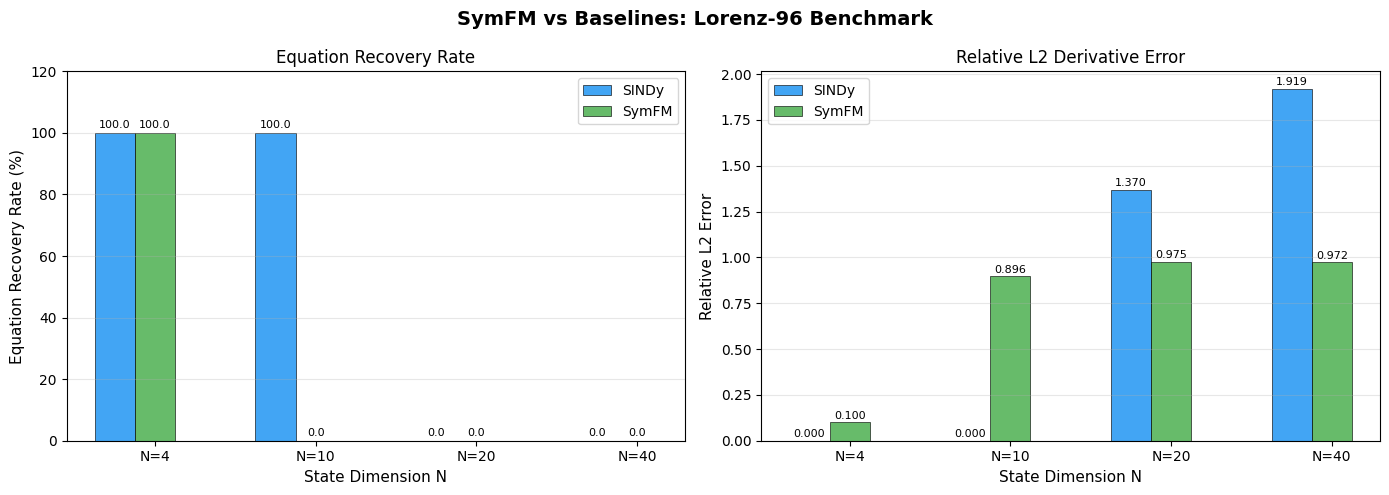

Figure saved: results/final_comparison.png


In [ ]:
dims = [4, 10, 20, 40]
methods = {
    'SINDy':  ('sindy',  '#2196F3'),
    'SymFM':  ('symfm',  '#4CAF50'),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SymFM vs Baselines: Lorenz-96 Benchmark',
             fontsize=14, fontweight='bold')

x    = np.arange(len(dims))
w    = 0.25
offs = [-0.25, 0.0, 0.25]

for ax_idx, metric in enumerate(['ERR_mean', 'L2_mean']):
    ax = axes[ax_idx]
    for i, (label, (key, color)) in enumerate(methods.items()):
        vals = []
        for N in dims:
            try:
                with open(f'results/{key}_N{N}.json') as f:
                    r = json.load(f)
                vals.append(r[metric])
            except:
                vals.append(0)
        bars = ax.bar(x + offs[i], vals, w, label=label,
                      color=color, alpha=0.85,
                      edgecolor='black', linewidth=0.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (1 if metric=='ERR_mean' else 0.01),
                    f'{v:.1f}' if metric=='ERR_mean' else f'{v:.3f}',
                    ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([f'N={d}' for d in dims])
    ax.set_xlabel('State Dimension N', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    if metric == 'ERR_mean':
        ax.set_ylabel('Equation Recovery Rate (%)', fontsize=11)
        ax.set_title('Equation Recovery Rate', fontsize=12)
        ax.set_ylim(0, 120)
    else:
        ax.set_ylabel('Relative L2 Error', fontsize=11)
        ax.set_title('Relative L2 Derivative Error', fontsize=12)

plt.tight_layout()
plt.savefig('results/final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: results/final_comparison.png')

## Step 11: Download All Results

In [ ]:
import shutil

# Zip all results for download
shutil.make_archive('SymFM_results', 'zip', 'results')
print('Results zipped: SymFM_results.zip')
print('Download it from the Files panel on the left.')
print()
print('Files in results/:')
for f in sorted(os.listdir('results')):
    size = os.path.getsize(f'results/{f}')
    print(f'  {f} ({size/1024:.1f} KB)')

Results zipped: SymFM_results.zip
Download it from the Files panel on the left.

Files in results/:
  final_comparison.png (79.9 KB)
  sindy_N10.json (0.2 KB)
  sindy_N20.json (0.2 KB)
  sindy_N4.json (0.2 KB)
  sindy_N40.json (0.2 KB)
  symfm_N10.json (0.2 KB)
  symfm_N10_trial0.pt (820.9 KB)
  symfm_N10_trial1.pt (820.9 KB)
  symfm_N10_trial2.pt (820.9 KB)
  symfm_N20.json (0.2 KB)
  symfm_N20_trial0.pt (895.9 KB)
  symfm_N20_trial1.pt (895.9 KB)
  symfm_N20_trial2.pt (895.9 KB)
  symfm_N4.json (0.2 KB)
  symfm_N40.json (0.2 KB)
  symfm_N40_trial0.pt (1030.7 KB)
  symfm_N40_trial1.pt (1030.7 KB)
  symfm_N40_trial2.pt (1030.7 KB)
  symfm_N4_trial0.pt (794.1 KB)
  symfm_N4_trial1.pt (794.1 KB)
  symfm_N4_trial2.pt (794.1 KB)
